Epoch 1, Train Loss: 1.9334, Train Acc: 34.85%, Val Loss: 1.5508, Val Acc: 40.30%, Test Acc: 40.58%


Epoch 2, Train Loss: 1.5194, Train Acc: 46.12%, Val Loss: 1.3769, Val Acc: 49.60%, Test Acc: 50.79%


Epoch 3, Train Loss: 1.3053, Train Acc: 53.52%, Val Loss: 1.2320, Val Acc: 55.90%, Test Acc: 56.09%


Epoch 4, Train Loss: 1.1273, Train Acc: 59.65%, Val Loss: 1.3174, Val Acc: 54.10%, Test Acc: 54.50%


Epoch 5, Train Loss: 0.9816, Train Acc: 64.17%, Val Loss: 1.0642, Val Acc: 62.90%, Test Acc: 60.62%


...

Epoch 21, Train Loss: 0.1334, Train Acc: 96.25%, Val Loss: 0.8663, Val Acc: 73.40%, Test Acc: 72.49%


Epoch 22, Train Loss: 0.1345, Train Acc: 95.90%, Val Loss: 0.9456, Val Acc: 73.10%, Test Acc: 71.56%


Epoch 23, Train Loss: 0.1294, Train Acc: 96.08%, Val Loss: 0.9189, Val Acc: 73.00%, Test Acc: 71.19%


Epoch 24, Train Loss: 0.1308, Train Acc: 96.22%, Val Loss: 0.9698, Val Acc: 72.10%, Test Acc: 70.66%


Epoch 25, Train Loss: 0.1337, Train Acc: 95.78%, Val Loss: 0.9199, Val Acc: 73.00%, Test Acc: 71.74%
Early stopping triggered.


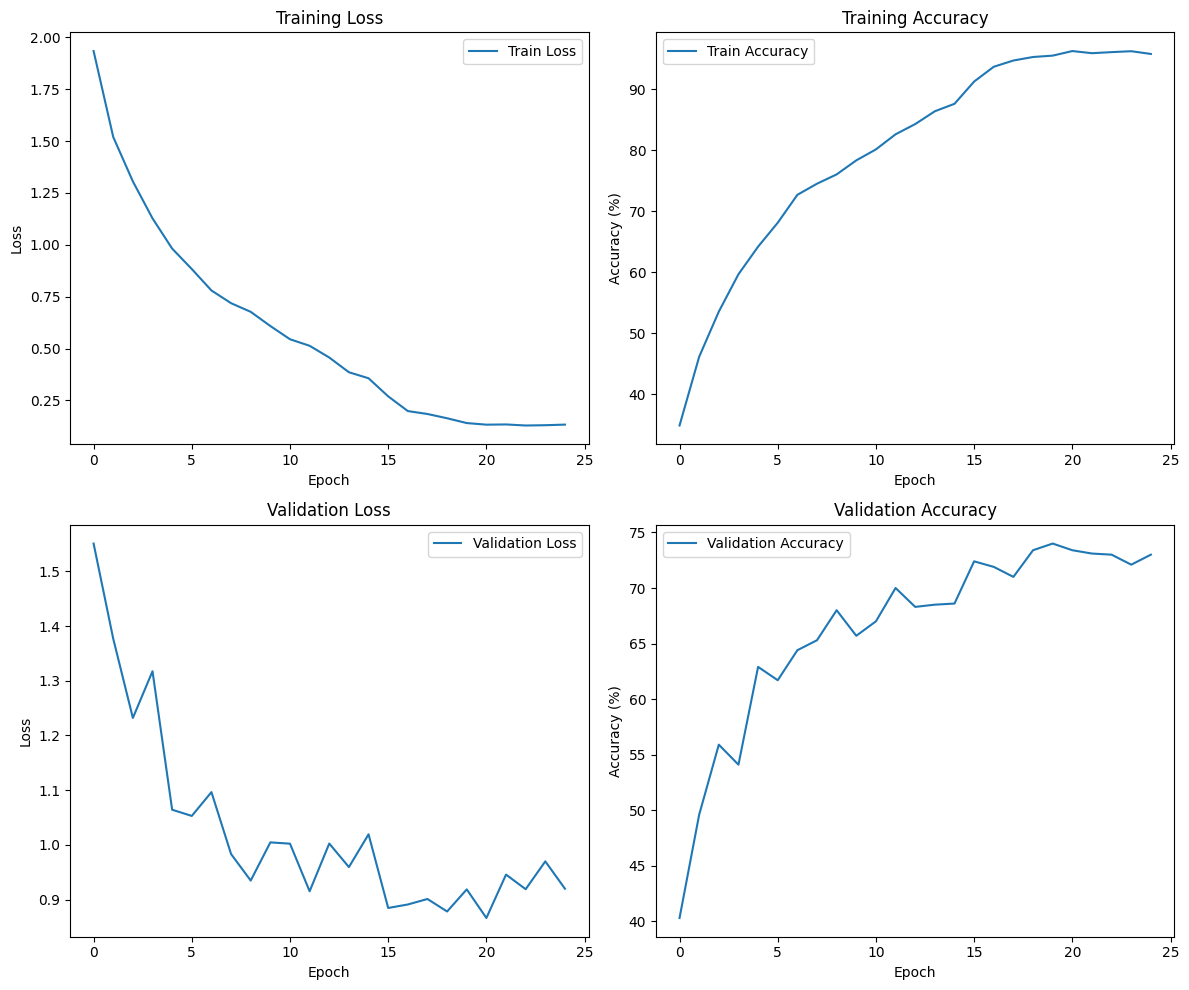

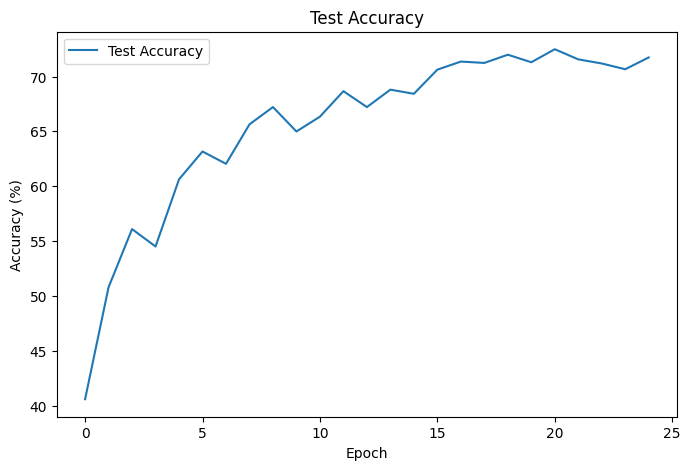

Test Accuracy: 71.10%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import STL10
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Initialization
def custom_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.1)

# Optimal CNN Model for STL-10
class OptimalCNN_STL10(nn.Module):
    def __init__(self, num_classes):
        super(OptimalCNN_STL10, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.4)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 12 * 12, 512),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Data Preparation with validation split
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train = STL10(root='./data', split='train', transform=transform, download=True)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = STL10(root='./data', split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Train Function with validation, test tracking and early stopping
def train_model(model, train_loader, val_loader, test_loader, epochs=50, patience=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    best_val_acc = 0
    patience_counter = 0
    train_losses, train_accuracies, val_losses, val_accuracies, test_accuracies = [], [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        scheduler.step()
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100 * correct_train / total_train)

        # Validation
        model.eval()
        correct_val, total_val = 0, 0
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = 100 * correct_val / total_val
        val_losses.append(running_val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        # Test
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        test_acc = 100 * correct_test / total_test
        test_accuracies.append(test_acc)

        print(
            f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, "
            f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.2f}%, Test Acc: {test_acc:.2f}%"
        )

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Plotting
    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

    # Load best model
    model.load_state_dict(torch.load("best_model.pt"))
    test_model(model, test_loader)

# Test Function
def test_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Run
model = OptimalCNN_STL10(num_classes=10)
model.apply(custom_init)
train_model(model, train_loader, val_loader, test_loader)
